# NLP Lab 4: Vector Semantics

**Course:** ART1501 – Natural Language Processing  
**Topics:** Term-Document Matrix, Cosine Similarity, and TF-IDF  
**Student Name:** ____________________  
**Student ID:** ____________________

## Objective

This notebook completes all three exercises in Lab 4 using the exact sentences provided in the lab manual.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

## Task 1: Count Vectorizer

Apply `CountVectorizer` to obtain the count of each word in the five book-title sentences. Rows represent sentences and columns represent terms.

In [2]:
count_documents = [
    "One Cent, Two Cents, Old Cent, New Cent: All About Money (Cat in the Hat's Learning Library",
    "Inside Your Outside: All About the Human Body (Cat in the Hat's Learning Library)",
    "Oh, The Things You Can Do That Are Good for You: All About Staying Healthy (Cat in the Hat's Learning Library)",
    "On Beyond Bugs: All About Insects (Cat in the Hat's Learning Library)",
    "There's No Place Like Space: All About Our Solar System (Cat in the Hat's Learning Library)"
]
count_labels = [f"Sentence {number}" for number in range(1, len(count_documents) + 1)]
count_vectorizer = CountVectorizer()
count_matrix = count_vectorizer.fit_transform(count_documents)
count_table = pd.DataFrame(
    count_matrix.toarray(),
    index=count_labels,
    columns=count_vectorizer.get_feature_names_out()
)
count_table.index.name = "Sentence"
count_table

,about,all,are,beyond,body,bugs,can,cat,cent,cents,do,for,good,hat,healthy,human,in,insects,inside,learning,library,like,money,new,no,oh,old,on,one,our,outside,place,solar,space,staying,system,that,the,there,things,two,you,your
Sentence,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Sentence 1,1,1,0,0,0,0,0,1,3,1,0,0,0,1,0,0,1,0,0,1,1,0,1,1,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0
Sentence 2,1,1,0,0,1,0,0,1,0,0,0,0,0,1,0,1,1,0,1,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,2,0,0,0,0,1
Sentence 3,1,1,1,0,0,0,1,1,0,0,1,1,1,1,1,0,1,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,2,0,1,0,2,0
Sentence 4,1,1,0,1,0,1,0,1,0,0,0,0,0,1,0,0,1,1,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
Sentence 5,1,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,1,1,1,0,0,1,0,0,0,0,1,0,1,1,1,0,1,0,1,1,0,0,0,0


In [3]:
term_frequency = count_table.sum().sort_values(ascending=False).to_frame("Total Count")
term_frequency.index.name = "Term"
term_frequency

,Total Count
Term,
the,7
all,5
about,5
in,5
library,5
hat,5
learning,5
cat,5
cent,3


### Task 1 Result

The vocabulary contains **43 unique terms**. The most frequent term is **the**, occurring **7 times**.

## Task 2: Cosine Similarity

Convert the four sentences into count vectors and calculate every pairwise cosine similarity. A value closer to 1 indicates greater similarity.

In [4]:
similarity_documents = [
    "This is the first document.",
    "This document is the second document.",
    "And this is the third one.",
    "Is this the first document?"
]
similarity_labels = [f"Sentence {number}" for number in range(1, len(similarity_documents) + 1)]
similarity_vectorizer = CountVectorizer()
similarity_vectors = similarity_vectorizer.fit_transform(similarity_documents)
similarity_matrix = cosine_similarity(similarity_vectors)
similarity_table = pd.DataFrame(
    similarity_matrix,
    index=similarity_labels,
    columns=similarity_labels
).round(4)
similarity_table.index.name = "Sentence"
similarity_table

,Sentence 1,Sentence 2,Sentence 3,Sentence 4
Sentence,,,,
Sentence 1,1.0000,0.7906,0.5477,1.0000
Sentence 2,0.7906,1.0000,0.4330,0.7906
Sentence 3,0.5477,0.4330,1.0000,0.5477
Sentence 4,1.0000,0.7906,0.5477,1.0000


In [5]:
similarity_pairs = []
for left_index in range(len(similarity_labels)):
    for right_index in range(left_index + 1, len(similarity_labels)):
        similarity_pairs.append({
            "Sentence Pair": f"{similarity_labels[left_index]} and {similarity_labels[right_index]}",
            "Cosine Similarity": similarity_matrix[left_index, right_index]
        })
similarity_ranking = pd.DataFrame(similarity_pairs).sort_values(
    "Cosine Similarity", ascending=False
).reset_index(drop=True)
similarity_ranking["Cosine Similarity"] = similarity_ranking["Cosine Similarity"].round(4)
similarity_ranking

,Sentence Pair,Cosine Similarity
0,Sentence 1 and Sentence 4,1.0000
1,Sentence 1 and Sentence 2,0.7906
2,Sentence 2 and Sentence 4,0.7906
3,Sentence 1 and Sentence 3,0.5477
4,Sentence 3 and Sentence 4,0.5477
5,Sentence 2 and Sentence 3,0.4330


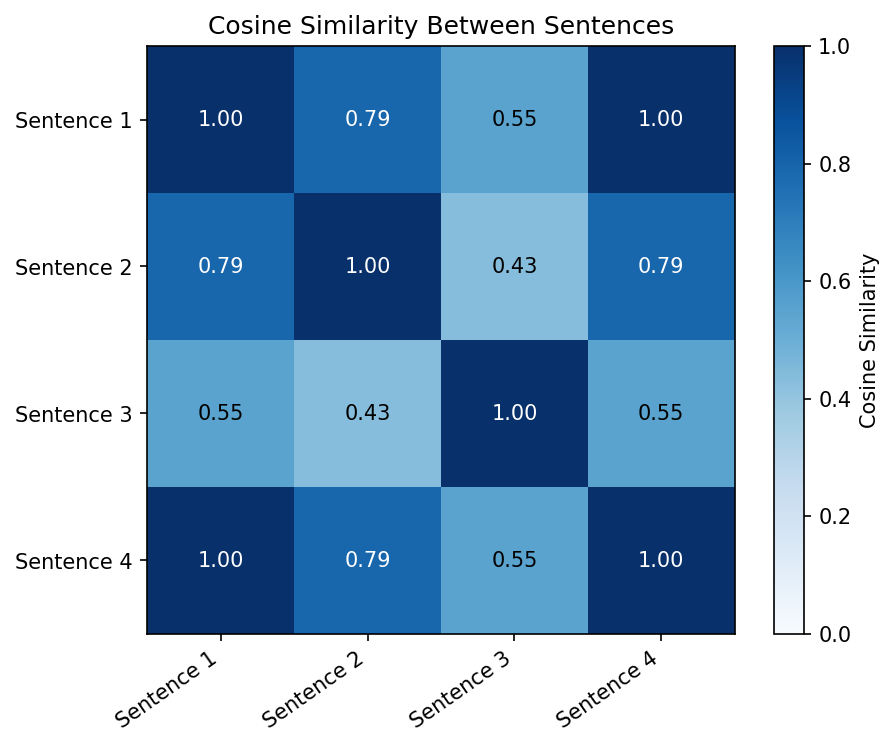

In [6]:
figure, axis = plt.subplots(figsize=(6.4, 5.1))
heatmap = axis.imshow(similarity_matrix, cmap="Blues", vmin=0, vmax=1)
axis.set_xticks(range(len(similarity_labels)), similarity_labels, rotation=35, ha="right")
axis.set_yticks(range(len(similarity_labels)), similarity_labels)
for row in range(similarity_matrix.shape[0]):
    for column in range(similarity_matrix.shape[1]):
        value = similarity_matrix[row, column]
        axis.text(column, row, f"{value:.2f}", ha="center", va="center", color="white" if value > 0.65 else "black")
axis.set_title("Cosine Similarity Between Sentences")
figure.colorbar(heatmap, ax=axis, label="Cosine Similarity")
figure.tight_layout()
plt.show()

### Task 2 Result

The most similar distinct pair is **Sentence 1 and Sentence 4**, with a cosine similarity of **1.0000**. These sentences contain the same words after tokenization, so their vectors point in the same direction.

## Task 3: TF-IDF

Apply TF-IDF to determine the important words in each sentence. Larger weights indicate terms that are more informative within a sentence relative to the full collection.

In [7]:
tfidf_documents = [
    "data science is one of the most important fields of science",
    "this is one of the best data science courses",
    "data scientists analyze data"
]
tfidf_labels = [f"Sentence {number}" for number in range(1, len(tfidf_documents) + 1)]
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(tfidf_documents)
tfidf_table = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=tfidf_labels,
    columns=tfidf_vectorizer.get_feature_names_out()
).round(4)
tfidf_table.index.name = "Sentence"
tfidf_table

,analyze,best,courses,data,fields,important,is,most,of,one,science,scientists,the,this
Sentence,,,,,,,,,,,,,,
Sentence 1,0.0000,0.0000,0.0000,0.1895,0.3209,0.3209,0.2440,0.3209,0.4881,0.2440,0.4881,0.0000,0.2440,0.0000
Sentence 2,0.0000,0.4003,0.4003,0.2364,0.0000,0.0000,0.3044,0.0000,0.3044,0.3044,0.3044,0.0000,0.3044,0.4003
Sentence 3,0.5427,0.0000,0.0000,0.6411,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5427,0.0000,0.0000


In [8]:
important_rows = []
for sentence in tfidf_table.index:
    positive_scores = tfidf_table.loc[sentence][tfidf_table.loc[sentence] > 0]
    for rank, (word, score) in enumerate(positive_scores.sort_values(ascending=False).head(5).items(), start=1):
        important_rows.append({
            "Sentence": sentence,
            "Rank": rank,
            "Word": word,
            "TF-IDF": score
        })
important_words = pd.DataFrame(important_rows).set_index(["Sentence", "Rank"])
important_words

Word  TF-IDF
Sentence   Rank                    
Sentence 1 1        science  0.4881
           2             of  0.4881
           3           most  0.3209
           4         fields  0.3209
           5      important  0.3209
Sentence 2 1           best  0.4003
           2        courses  0.4003
           3           this  0.4003
           4             of  0.3044
           5             is  0.3044
Sentence 3 1           data  0.6411
           2        analyze  0.5427
           3     scientists  0.5427

### Task 3 Result

The TF-IDF matrix and ranking table identify the most informative terms in each sentence. Repeated terms such as **data** receive lower discriminative weight, while sentence-specific terms such as **important**, **fields**, **courses**, **scientists**, and **analyze** receive higher weights.

## Conclusion

CountVectorizer created a term-document matrix of raw word frequencies, cosine similarity measured the direction-based similarity between sentence vectors, and TF-IDF emphasized terms that best distinguish each sentence from the collection.